<span style="color: blue;">**Predicting Customer Churn**</span>

**Project Overview**

This project builds a machine learning model to predict whether a customer will churn (leave a service) or remain active based on customer demographics, account information, and service usage patterns. Supervised classification techniques are applied to identify behavioral and contractual factors that influence customer retention.

To select the most effective model, multiple algorithms including XGBoost, Random Forest, K-Nearest Neighbors, Decision Tree, and Logistic Regression were evaluated using Stratified Cross-Validation with F1-score to ensure reliable performance under class imbalance conditions. The best-performing model (Logistic Regression) was then further optimized using Bayesian Optimization for hyperparameter tuning, improving predictive performance before deployment in a Streamlit web application for real-time churn prediction.

**Live Application (Streamlit):**

[Customer Churn Prediction](https://customer-churn-prediction-gejdn7bzopuux4djprncx4.streamlit.app/)

The deployed web application allows users to input customer demographic and service-related details and receive real-time predictions on whether a customer is likely to churn or remain subscribed.

In [1]:
# Data Handling & Visualization Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing & Feature Engineering
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import RFE

# Model Selection & Validation
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

#  Machine Learning Models
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

#  Model Evaluation Metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
# Data Loading & Initial Inspection
pd.set_option('display.max_columns', None)

df = pd.read_csv('train.csv')
df.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [3]:
# Dataset Dimensions
print('Column number:', df.shape[1])
print('Row number:', df.shape[0])

Column number: 21
Row number: 594194


In [4]:
# Check for Duplicate Records
df.duplicated().sum()

np.int64(0)

In [5]:
# Check for Missing Values
df.isnull().sum()

,0
id,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [6]:
# Handle Missing Values (Drop Nulls)
df.dropna(inplace = True)

In [7]:
# Drop Irrelevant Identifier Column
df.drop('id', axis=1, inplace=True)

In [8]:
# Analyze Categorical Features (Unique Values)
df.select_dtypes(include='object').nunique()

,0
gender,2
Partner,2
Dependents,2
PhoneService,2
MultipleLines,3
InternetService,3
OnlineSecurity,3
OnlineBackup,3
DeviceProtection,3
TechSupport,3


In [9]:
# Analyze Target Variable Distribution (Churn %)
df['Churn'].value_counts(normalize=True) * 100

,proportion
Churn,
No,77.479241
Yes,22.520759


In [10]:
# Summary Statistics of Numerical Features
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,594194.000000,594194.000000,594194.000000,594194.000000
mean,0.114102,36.577258,65.866223,2494.377057
std,0.317936,25.061922,31.067444,2353.916710
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,12.000000,29.900000,639.650000
50%,0.000000,35.000000,74.100000,1433.650000
75%,0.000000,62.000000,90.800000,4263.800000
max,1.000000,72.000000,118.750000,8684.800000


In [11]:
# Separate Categorical and Numerical Features
cat = df.select_dtypes(include='object')
num = df.select_dtypes(exclude='object')

print('Categorical Features:', cat.columns.tolist())
print('Numerical Features:', num.columns.tolist())

Categorical Features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']
Numerical Features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [12]:
# Check Skewness of Numerical Features
num.skew()

,0
SeniorCitizen,2.427526
tenure,0.063050
MonthlyCharges,-0.289486
TotalCharges,0.909169


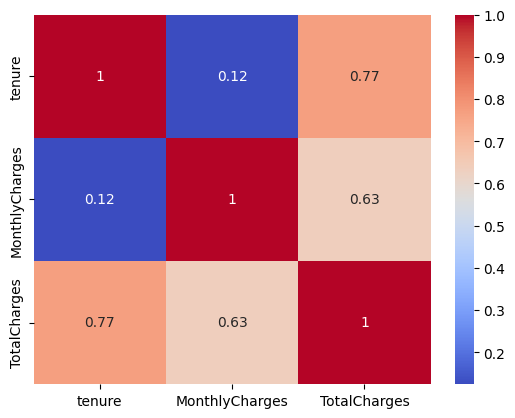

In [13]:
# Correlation Analysis of Numerical Features
num = df[['tenure','MonthlyCharges','TotalCharges']]
corr = num.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [14]:
# Remove Redundant Feature to Reduce Multicollinearity
df.drop('TotalCharges', axis=1, inplace=True)

TotalCharges was highly correlated with tenure (0.77) and MonthlyCharges (0.63).
This indicated redundancy and potential multicollinearity in the dataset.
It was therefore dropped to improve model stability and reduce overlapping information.

In [15]:
# Class Imbalance Check (Churn Ratio)
counts = df['Churn'].value_counts()
ratio = counts['No'] / counts['Yes']
print(ratio)

3.440347638939746


The churn ratio is 3.44, meaning there are about 3.4 non-churning customers for every 1 churning customer.
This confirms a moderate class imbalance, which is why techniques like SMOTE and class weighting were applied during modeling.

In [16]:
# Encode Binary Categorical Variables
df['gender'] = df['gender'].map({'Male':1, 'Female':0})
df['Partner'] = df['Partner'].map({'Yes':1, 'No':0})
df['Dependents'] = df['Dependents'].map({'Yes':1, 'No':0})
df['PhoneService'] = df['PhoneService'].map({'Yes':1, 'No':0})
df['PaperlessBilling'] = df['PaperlessBilling'].map({'Yes':1, 'No':0})
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

In [17]:
# One-Hot Encoding of Multi-Class Categorical Features
categorical_cols = [
'MultipleLines','InternetService','OnlineSecurity','OnlineBackup',
'DeviceProtection','TechSupport','StreamingTV','StreamingMovies',
'Contract','PaymentMethod'
]

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [18]:
# Preview Processed Dataset
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,1,29,1,1,60.10,0,False,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,True
1,1,0,1,1,58,1,0,69.50,0,False,False,False,False,False,True,False,True,False,False,False,True,False,True,False,False,False,True,True,False,False
2,1,0,1,0,58,1,1,100.40,0,False,True,True,False,False,False,False,True,False,False,False,False,False,True,False,True,False,False,False,True,False
3,0,0,0,0,1,1,1,69.70,1,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
4,0,0,0,0,1,1,1,70.45,1,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False


In [19]:
# Split Features and Target Variable
X = df.drop('Churn', axis=1)
y = df['Churn']

In [20]:
# Train-Test Split (Stratified Sampling)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [21]:
# Class Imbalance Ratio for XGBoost (scale_pos_weight)

# Count classes
neg = (y_train == 1).sum()
pos = (y_train == 0).sum()

# Compute ratio
ratio = neg / pos
print("scale_pos_weight ratio:", ratio)

scale_pos_weight ratio: 0.2906698597071417


The computed scale_pos_weight ratio is 0.29, indicating that the churn (positive class) is significantly underrepresented compared to non-churned customers.
This imbalance value is used in XGBoost to give higher importance to the minority class during training, improving churn detection performance

In [22]:
# Model Comparison Using Cross-Validation (F1 Score)

models = {
    'XGBoost': XGBClassifier(random_state=42, scale_pos_weight=ratio),
    'RandomForest': RandomForestClassifier(random_state=42, class_weight='balanced'),
    'KNN': KNeighborsClassifier(),
    'DecisionTree': DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42)
}

# Cross-validation setup
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Run CV and collect results
cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=kf, scoring='f1')
    cv_results[name] = scores.mean()
    print(f"{name} Average CV F1: {scores.mean():.4f}")

# Find best model
best_model_name = max(cv_results, key=cv_results.get)
print("\nBest Model Based on CV F1:", best_model_name)

XGBoost Average CV F1: 0.4024
RandomForest Average CV F1: 0.6143
KNN Average CV F1: 0.6309
DecisionTree Average CV F1: 0.5761
LogisticRegression Average CV F1: 0.6642

Best Model Based on CV F1: LogisticRegression


Among all evaluated models, Logistic Regression achieved the highest cross-validation accuracy and was selected as the best baseline model. However, in practice, F1-score is typically preferred for this problem due to class imbalance, as it better reflects performance on the minority (churn) class.

In [23]:
# Install Hyperparameter Optimization Library
!pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 3.3 MB/s eta 0:00:00


In [24]:
# Import Bayesian Hyperparameter Optimization Tool
from skopt import BayesSearchCV

In [ ]:
# Model Building: Bagging Logistic Regression with Bayesian Optimization

# Step 1: Base logistic regression
logreg = LogisticRegression(
    solver='liblinear',
    random_state=42,
    class_weight='balanced'
)

# Step 2: Bagging wrapper
bagging_logreg = BaggingClassifier(
    estimator=logreg,
    bootstrap=True,
    random_state=42
)

# Step 3: Define the pipeline
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('classifier', bagging_logreg)
])
# Step 4: Define hyperparameter search space
search_space = {
    # Bagging hyperparameters
    'classifier__n_estimators': (10, 50),
    'classifier__max_samples': (0.5, 1.0),
    'classifier__max_features': (0.5, 1.0),

    # Logistic Regression hyperparameters (inside Bagging)
    'classifier__estimator__C': (0.01, 10.0, 'log-uniform'),
    'classifier__estimator__penalty': ['l1', 'l2']
}

# Step 5: Cross-validation
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Step 6: Bayesian optimization
bayes_opt = BayesSearchCV(
    estimator=pipeline,
    search_spaces=search_space,
    n_iter=15,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# Step 7: Fit the model
bayes_opt.fit(X_train, y_train)

# Step 8: Best parameters and score
print("Best Parameters:", bayes_opt.best_params_)
print("Best F1 Score:", bayes_opt.best_score_)

Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Best Parameters: OrderedDict({'classifier__estimator__C': 9.257554466312863, 'classifier__estimator__penalty': 'l2'

In [ ]:
# Model Evaluation (Train & Test Performance)

# Get the best trained pipeline
best_model = bayes_opt.best_estimator_

# Predictions
y_pred_train = best_model.predict(X_train)
y_pred_test = best_model.predict(X_test)

# Classification Report (Train & Test Evaluation)
print("\nClassification Report (Train):")
print(classification_report(y_train, y_pred_train))

print("\nClassification Report (Test):")
print(classification_report(y_test, y_pred_test))


Classification Report (Train):
              precision    recall  f1-score   support

           0       0.95      0.81      0.87    368301
           1       0.56      0.84      0.67    107054

    accuracy                           0.82    475355
   macro avg       0.75      0.83      0.77    475355
weighted avg       0.86      0.82      0.83    475355


Classification Report (Test):
              precision    recall  f1-score   support

           0       0.95      0.80      0.87     92076
           1       0.56      0.85      0.67     26763

    accuracy                           0.81    118839
   macro avg       0.75      0.83      0.77    118839
weighted avg       0.86      0.81      0.83    118839



The model performs well and shows strong generalization, achieving an accuracy of about 82% on the training set and 81% on the test set, indicating no significant overfitting. For class 0 (non-churn customers), the model performs very strongly with a precision of 0.95 and an F1-score of 0.87, meaning it reliably identifies customers who are likely to stay. For class 1 (churn customers), the model achieves a recall of about 0.84-0.85, which is important because it successfully captures most customers who are at risk of leaving. However, the precision for churn prediction is lower at 0.56, meaning some customers are incorrectly flagged as potential churners

In [ ]:
# Feature Selection Using RFE (Recursive Feature Elimination)
rfe = RFE(estimator=logreg, n_features_to_select=24)

rfe.fit(X_train, y_train)

RFE(estimator=LogisticRegression(class_weight='balanced', random_state=42,
                                 solver='liblinear'),
    n_features_to_select=24)

In [ ]:
# Extract Selected Features from RFE
selected_features = X_train.columns[rfe.support_]

print("Selected Features:")
print(selected_features)

Selected Features:
Index(['SeniorCitizen', 'Dependents', 'tenure', 'PhoneService',
       'PaperlessBilling', 'MultipleLines_No phone service',
       'MultipleLines_Yes', 'InternetService_Fiber optic',
       'InternetService_No', 'OnlineSecurity_No internet service',
       'OnlineSecurity_Yes', 'OnlineBackup_No internet service',
       'OnlineBackup_Yes', 'DeviceProtection_No internet service',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')


In [ ]:
# View Training Feature Columns
X_train.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'PaperlessBilling', 'MonthlyCharges',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')

In [ ]:
# Manually Defined RFE Selected Features
rfe_selected_features = [
'SeniorCitizen',
'Dependents',
'tenure',
'PhoneService',
'PaperlessBilling',
'MultipleLines_No phone service',
'MultipleLines_Yes',
'InternetService_Fiber optic',
'InternetService_No',
'OnlineSecurity_No internet service',
'OnlineSecurity_Yes',
'DeviceProtection_No internet service',
'DeviceProtection_Yes',
'TechSupport_No internet service',
'TechSupport_Yes',
'StreamingTV_No internet service',
'StreamingTV_Yes',
'StreamingMovies_No internet service',
'StreamingMovies_Yes',
'Contract_One year',
'Contract_Two year',
'PaymentMethod_Credit card (automatic)',
'PaymentMethod_Electronic check',
'PaymentMethod_Mailed check'
]

In [ ]:
# Filter Training and Test Sets Using RFE-Selected Features
X_train_rfe = X_train[rfe_selected_features]
X_test_rfe = X_test[rfe_selected_features]

In [ ]:
# Final Model Training: Optimized Bagging Logistic Regression

# # Best hyperparameters from Bayesian Optimization
best_params = {
    'C': 9.257554466312863,
    'penalty': 'l2',
    'n_estimators': 10,
    'max_samples': 0.5115399349568258,
    'max_features': 0.9912449123522021
}

# # Logistic Regression model with tuned parameters
logreg_best = LogisticRegression(
    solver='liblinear',
    C=best_params['C'],
    penalty=best_params['penalty'],
    random_state=42,
    class_weight='balanced'
)

# Bagging Classifier
bagging_best = BaggingClassifier(
    estimator=logreg_best,
    n_estimators=best_params['n_estimators'],
    max_samples=best_params['max_samples'],
    max_features=best_params['max_features'],
    bootstrap=True,
    random_state=42
)

# Pipeline: Scaling → SMOTE → Model
pipeline_best = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('classifier', bagging_best)
])

# Train final model
pipeline_best.fit(X_train_rfe, y_train)

# Predictions
y_pred_train = pipeline_best.predict(X_train_rfe)
y_pred_test = pipeline_best.predict(X_test_rfe)

# Evaluation
print("Classification Report: TRAIN")
print(classification_report(y_train, y_pred_train))

print("\nClassification Report: TEST")
print(classification_report(y_test, y_pred_test))

Classification Report: TRAIN
              precision    recall  f1-score   support

           0       0.96      0.79      0.86    368301
           1       0.55      0.87      0.67    107054

    accuracy                           0.81    475355
   macro avg       0.75      0.83      0.77    475355
weighted avg       0.86      0.81      0.82    475355


Classification Report: TEST
              precision    recall  f1-score   support

           0       0.96      0.79      0.86     92076
           1       0.55      0.87      0.67     26763

    accuracy                           0.81    118839
   macro avg       0.75      0.83      0.77    118839
weighted avg       0.86      0.81      0.82    118839



In [ ]:
# Save Trained Model for Deployment
import joblib

joblib.dump(pipeline_best,'pipeline.pkl')

['pipeline.pkl']

In [ ]:
# Check Scikit-Learn Version
import sklearn
print(sklearn.__version__)

1.6.1


**Conclusion:**

The development of the Customer Churn Prediction system demonstrates the effectiveness of machine learning in addressing customer retention challenges in subscription-based services. By analyzing customer demographics, account information, and service usage patterns, the model successfully identifies customers who are likely to churn, enabling early intervention and targeted retention strategies.

The system leverages multiple supervised learning algorithms, including Logistic Regression, Random Forest, K-Nearest Neighbors, Decision Tree, and XGBoost, evaluated using Stratified Cross-Validation with the F1-score to ensure robust performance under class imbalance conditions. To further enhance predictive accuracy, the final model incorporates feature selection using Recursive Feature Elimination (RFE), class imbalance handling through SMOTE, and hyperparameter optimization using Bayesian Search.

Ultimately, this predictive system provides actionable insights that support data-driven decision-making for customer retention strategies. By identifying at-risk customers in advance, businesses can proactively reduce churn, improve customer satisfaction, and increase long-term revenue. The deployment of the model through an interactive Streamlit application further bridges the gap between machine learning development and real-world business application, enabling real-time churn prediction in a practical and user-friendly interface.